<a href="https://colab.research.google.com/github/shriya-0802/KneeOsteoArthritis/blob/main/Efficient_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import os
import time
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import shutil
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import time

In [1]:
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [6]:

train_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/train'
test_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/test'
valid_path = '/content/drive/MyDrive/Kaggle_Dataset/archive (3)/val'
list_of_classes=['Healthy', 'Moderate', 'Severe']


In [7]:
for d in [train_path, test_path, valid_path]:
    filepaths = []
    labels = []

    classlist = os.listdir(d)

    for klass in classlist:
        # ✅ FIX: use folder name directly as label
        label = klass

        classpath = os.path.join(d, klass)
        flist = os.listdir(classpath)

        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(label)

    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')
    pdf = pd.concat([Fseries, Lseries], axis=1)

    if d == test_path:
        test_df = pdf
    elif d == valid_path:
        valid_df = pdf
    else:
        train_df = pdf

print('train_df lenght: ', len(train_df),
      '  test_df length: ', len(test_df),
      '  valid_df length: ', len(valid_df))

# =========================
# CLASS ANALYSIS
# =========================
classes = sorted(list(train_df['labels'].unique()))
class_count = len(classes)

print('The number of classes in the dataset is: ', class_count)

groups = train_df.groupby('labels')

print('{0:^30s} {1:^13s}'.format('CLASS', 'IMAGE COUNT'))

countlist = []
classlist = []

for label in classes:
    group = groups.get_group(label)
    countlist.append(len(group))
    classlist.append(label)

    print('{0:^30s} {1:^13s}'.format(label, str(len(group))))

# =========================
# MAX / MIN CLASS
# =========================
max_value = np.max(countlist)
max_index = countlist.index(max_value)
max_class = classlist[max_index]

min_value = np.min(countlist)
min_index = countlist.index(min_value)
min_class = classlist[min_index]

print(max_class, ' has the most images = ', max_value,
      ' ', min_class, ' has the least images = ', min_value)

# =========================
# IMAGE SIZE ANALYSIS
# =========================
ht = 0
wt = 0

# sample 100 images
train_df_sample = train_df.sample(n=100, random_state=123, axis=0)

for i in range(len(train_df_sample)):
    fpath = train_df_sample['filepaths'].iloc[i]
    img = plt.imread(fpath)

    shape = img.shape
    ht += shape[0]
    wt += shape[1]

print('average height = ', ht // 100,
      ' average width = ', wt // 100,
      ' aspect ratio = ', ht / wt)

train_df lenght:  5790   test_df length:  1656   valid_df length:  826
The number of classes in the dataset is:  5
            CLASS               IMAGE COUNT 
              0                    2298     
              1                    1046     
              2                    1516     
              3                     757     
              4                     173     
0  has the most images =  2298   4  has the least images =  173
average height =  224  average width =  224  aspect ratio =  1.0


In [8]:
def trim(df, max_samples, min_samples, column):
    df=df.copy()
    groups=df.groupby(column)
    trimmed_df = pd.DataFrame(columns = df.columns)
    groups=df.groupby(column)
    for label in df[column].unique():
        group=groups.get_group(label)
        count=len(group)
        if count > max_samples:
            sampled_group=group.sample(n=max_samples, random_state=123,axis=0)
            trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
        else:
            if count>=min_samples:
                sampled_group=group
                trimmed_df=pd.concat([trimmed_df, sampled_group], axis=0)
    print('after trimming, the maximum samples in any class is now ',max_samples, ' and the minimum samples in any class is ', min_samples)
    return trimmed_df

max_samples=500 # since each class has more than 200 images all classes will be trimmed to have 200 images per class
min_samples=173
column='labels'
train_df= trim(train_df, max_samples, min_samples, column)

after trimming, the maximum samples in any class is now  500  and the minimum samples in any class is  173


In [9]:
def balance(df, n, working_dir, img_size):
    df=df.copy()
    print('Initial length of dataframe is ', len(df))
    aug_dir=os.path.join(working_dir, 'aug')
    if os.path.isdir(aug_dir):
        shutil.rmtree(aug_dir)
    os.mkdir(aug_dir)
    for label in df['labels'].unique():
        dir_path=os.path.join(aug_dir,label)
        os.mkdir(dir_path)
    # create and store the augmented images
    total=0
    gen=ImageDataGenerator(horizontal_flip=True,  rotation_range=20, width_shift_range=.2,height_shift_range=.2, zoom_range=.2)
    groups=df.groupby('labels')
    for label in df['labels'].unique():
        group=groups.get_group(label)
        sample_count=len(group)
        if sample_count< n:
            aug_img_count=0
            delta=n - sample_count
            target_dir=os.path.join(aug_dir, label)  # define where to write the images
            msg='{0:40s} for class {1:^30s} creating {2:^5s} augmented images'.format(' ', label, str(delta))
            print(msg, '\r', end='')
            aug_gen=gen.flow_from_dataframe( group,  x_col='filepaths', y_col=None, target_size=img_size,
                                            class_mode=None, batch_size=1, shuffle=False,
                                            save_to_dir=target_dir, save_prefix='aug-', color_mode='rgb',
                                            save_format='jpg')
            while aug_img_count<delta:
                images=next(aug_gen)
                aug_img_count += len(images)
            total +=aug_img_count
    print('Total Augmented images created= ', total)
    # create aug_df and merge with train_df to create composite training set ndf
    aug_fpaths=[]
    aug_labels=[]
    classlist=os.listdir(aug_dir)
    for klass in classlist:
        classpath=os.path.join(aug_dir, klass)
        flist=os.listdir(classpath)
        for f in flist:
          fpath=os.path.join(classpath,f)
          aug_fpaths.append(fpath)
          aug_labels.append(klass)
    Fseries=pd.Series(aug_fpaths, name='filepaths')
    Lseries=pd.Series(aug_labels, name='labels')
    aug_df=pd.concat([Fseries, Lseries], axis=1)
    df=pd.concat([df,aug_df], axis=0).reset_index(drop=True)
    print('Length of augmented dataframe is now ', len(df))
    return df

n=500
working_dir=r'./'
img_size=(224,224)
train_df=balance(train_df, n, working_dir, img_size)

Initial length of dataframe is  2173
Found 173 validated image filenames.
Total Augmented images created=  327
Length of augmented dataframe is now  2500


In [10]:
def relabel(label_in):
    if label_in =='Healthy' or label_in == 'Doubtful' or label_in =='Minimal':
        label='Healthy'
    else:
        label=label_in
    return label


for df in [train_df, test_df, valid_df]:
    for i in range (len(df)):
        label=df['labels'].iloc[i]
        new_label=relabel(label)
        df['labels'].iloc[i]=new_label
print (train_df['labels'].value_counts())

/tmp/ipykernel_3725/2821975925.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['labels'].iloc[i]=new_label


labels
4    500
2    500
3    500
0    500
1    500
Name: count, dtype: int64


In [11]:
max_samples=500
min_samples=500
column='labels'
train_df= trim(train_df, max_samples, min_samples, column)

after trimming, the maximum samples in any class is now  500  and the minimum samples in any class is  500


In [12]:
batch_size=20
trgen=ImageDataGenerator(horizontal_flip=True,rotation_range=20 )
t_and_v_gen=ImageDataGenerator()
msg='{0:70s} for train generator'.format(' ')
print(msg, '\r', end='')
train_gen=trgen.flow_from_dataframe(train_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)
msg='{0:70s} for valid generator'.format(' ')
print(msg, '\r', end='')
valid_gen=t_and_v_gen.flow_from_dataframe(valid_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)

length=len(test_df)
test_batch_size=sorted([int(length/n) for n in range(1,length+1) if length % n ==0 and length/n<=80],reverse=True)[0]
test_steps=int(length/test_batch_size)
msg='{0:70s} for test generator'.format(' ')
print(msg, '\r', end='')
test_gen=t_and_v_gen.flow_from_dataframe(test_df, x_col='filepaths', y_col='labels', target_size=img_size,
                                   class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=test_batch_size)

classes=list(train_gen.class_indices.keys())
class_indices=list(train_gen.class_indices.values())
class_count=len(classes)
labels=test_gen.labels
print ( 'test batch size: ' ,test_batch_size, '  test steps: ', test_steps, ' number of classes : ', class_count)

Found 2500 validated image filenames belonging to 5 classes.
Found 826 validated image filenames belonging to 5 classes.
Found 1656 validated image filenames belonging to 5 classes.
test batch size:  72   test steps:  23  number of classes :  5


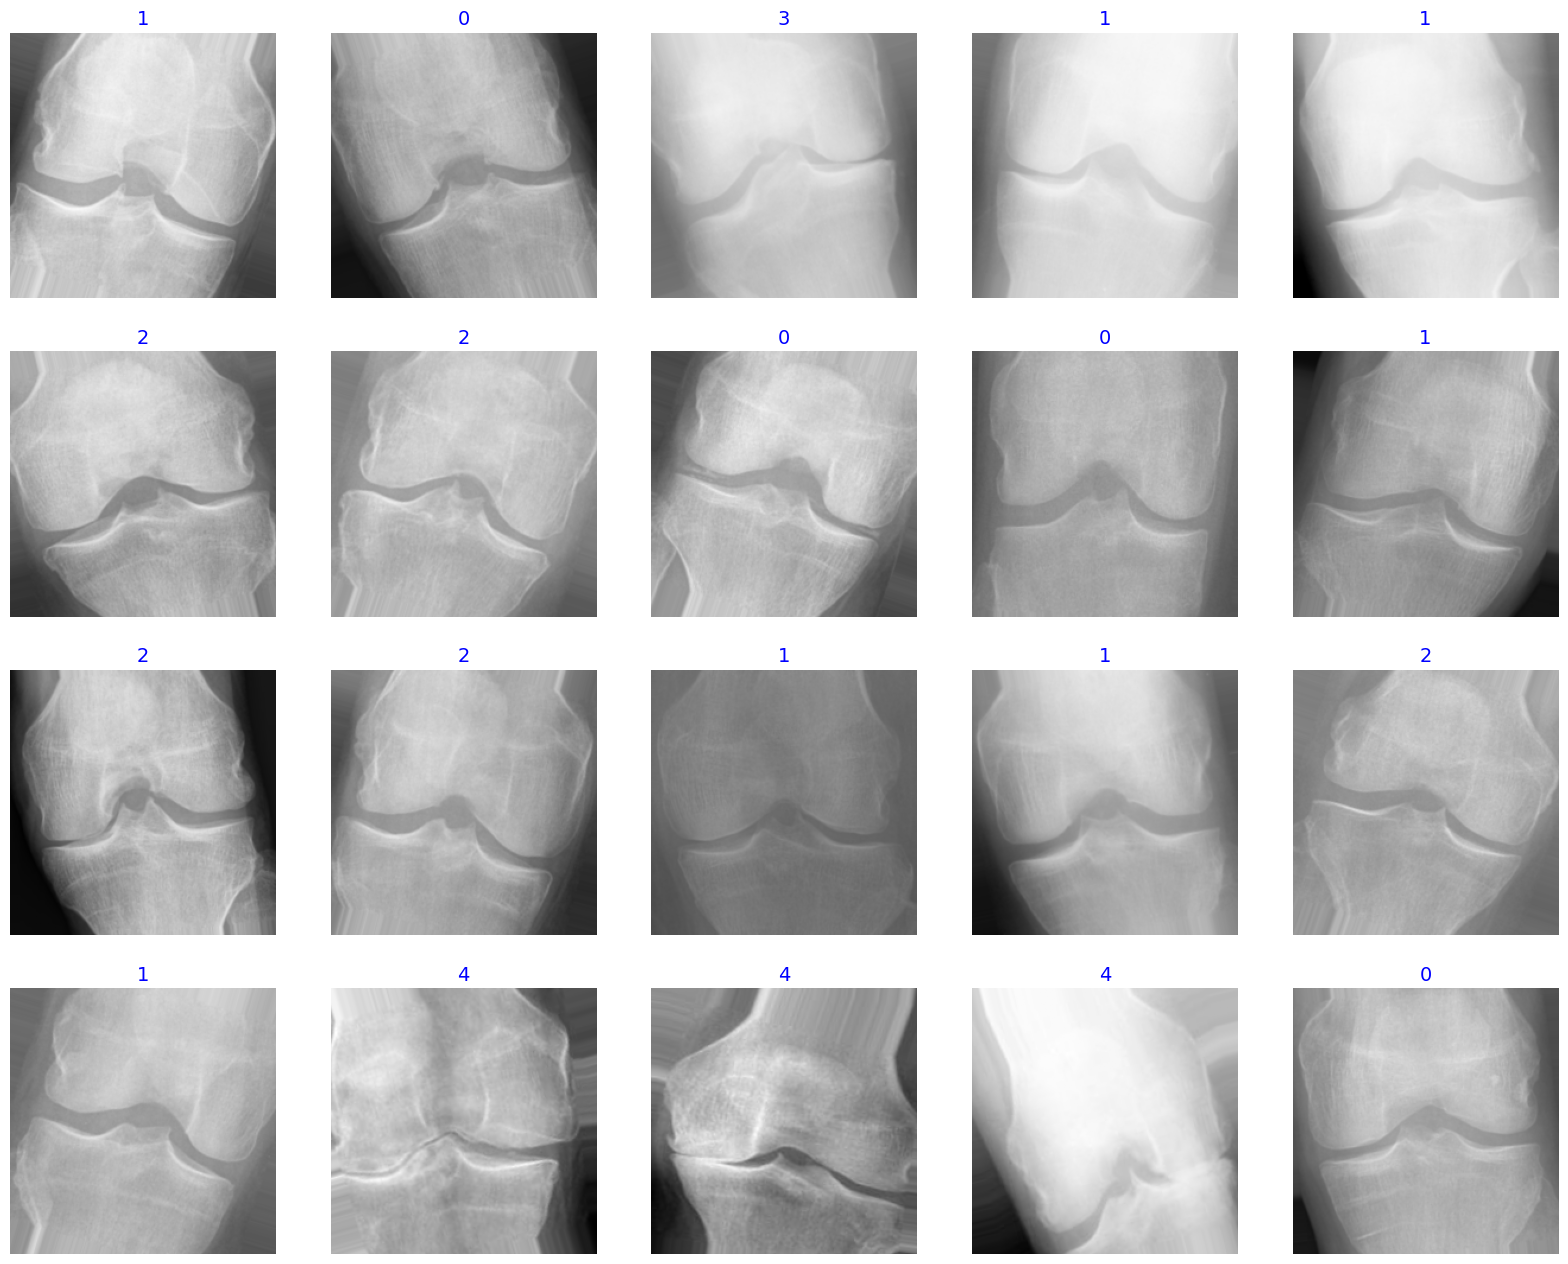

In [13]:
def show_image_samples(gen ):
    t_dict=gen.class_indices
    classes=list(t_dict.keys())
    images,labels=next(gen)
    plt.figure(figsize=(20, 20))
    length=len(labels)
    if length<25:
        r=length
    else:
        r=25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image=images[i] /255
        plt.imshow(image)
        index=np.argmax(labels[i])
        class_name=classes[index]
        plt.title(class_name, color='blue', fontsize=14)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen )

In [14]:
K.clear_session()
tf.compat.v1.reset_default_graph()

img_shape=(img_size[0], img_size[1], 3)

model_name='EfficientNetB5'

base_model=tf.keras.applications.efficientnet.EfficientNetB5(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable=True

x=base_model.output

x=BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

# ✅ FIXED ONLY THIS LINE
x = Dense(256,
          kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation='relu')(x)

x=Dropout(rate=.4, seed=123)(x)

output=Dense(class_count, activation='softmax')(x)

model=Model(inputs=base_model.input, outputs=output)

lr=.001

model.compile(Adamax(learning_rate=lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

115263384/115263384 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [15]:
epochs=25
ask_epoch=10

In [16]:
new_history=model.fit(x=train_gen,  epochs=epochs, verbose=1, validation_data=valid_gen,
               validation_steps=None,  shuffle=False,  initial_epoch=0)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 1198s 8s/step - accuracy: 0.2308 - loss: 11.1817 - val_accuracy: 0.2228 - val_loss: 7.8423
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 471ms/step - accuracy: 0.2148 - loss: 7.4405 - val_accuracy: 0.2663 - val_loss: 7.0354
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 483ms/step - accuracy: 0.1964 - loss: 6.6762 - val_accuracy: 0.1852 - val_loss: 6.2910
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 475ms/step - accuracy: 0.1996 - loss: 5.9484 - val_accuracy: 0.1852 - val_loss: 5.5964
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 463ms/step - accuracy: 0.1996 - loss: 5.2907 - val_accuracy: 0.2579 - val_loss: 4.9764
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 461ms/step - accuracy: 0.1912 - loss: 4.7358 - val_accuracy: 0.2567 - val_loss: 4.4755
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 464ms/step - accuracy: 0.1880 - loss: 4.2333 - val_accuracy: 0.1852 - val_loss: 4.0047
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 453ms/step - accuracy: 0.1976 - loss: 3

In [17]:
def predictor(test_gen, test_steps):
    y_pred= []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    print(f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}')
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(12, 8))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests

23/23 ━━━━━━━━━━━━━━━━━━━━ 520s 22s/step
there were 1323 errors in 1656 tests for an accuracy of  20.11


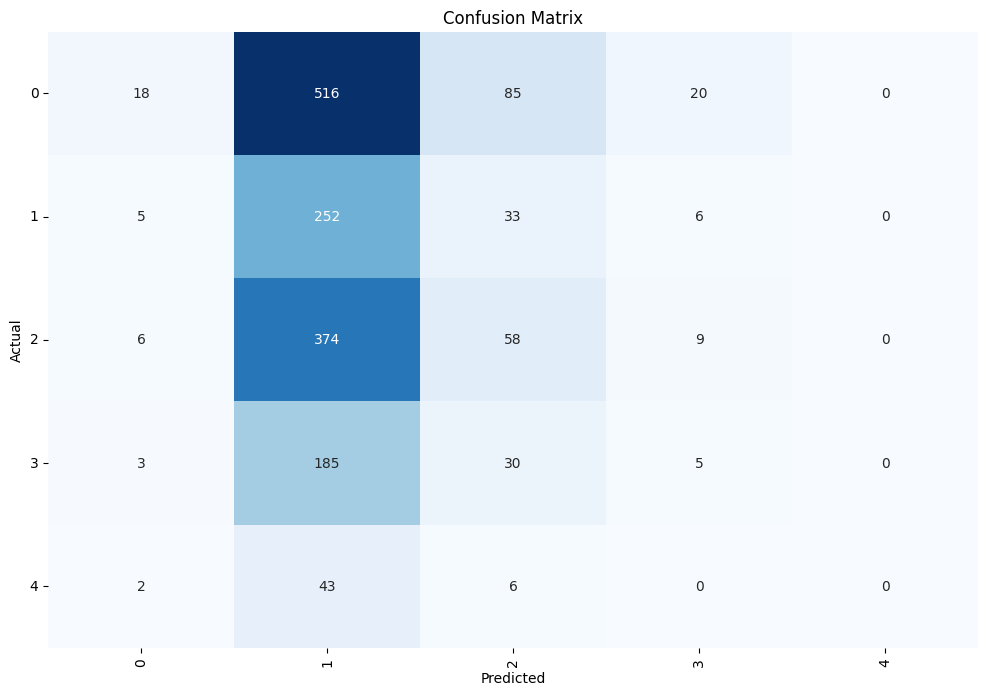

Classification Report:
----------------------
               precision    recall  f1-score   support

           0     0.5294    0.0282    0.0535       639
           1     0.1839    0.8514    0.3025       296
           2     0.2736    0.1298    0.1760       447
           3     0.1250    0.0224    0.0380       223
           4     0.0000    0.0000    0.0000        51

    accuracy                         0.2011      1656
   macro avg     0.2224    0.2063    0.1140      1656
weighted avg     0.3278    0.2011    0.1273      1656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
errors, tests=predictor(test_gen, test_steps)

In [19]:
K.clear_session()
tf.compat.v1.reset_default_graph()

img_shape=(img_size[0], img_size[1], 3)

model_name='EfficientNetB5'

base_model=tf.keras.applications.efficientnet.EfficientNetB5(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

base_model.trainable=True

x=base_model.output

x=BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

# ✅ FIXED ONLY THIS LINE
x = Dense(256,
          kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation='relu')(x)

x=Dropout(rate=.4, seed=123)(x)

output=Dense(class_count, activation='softmax')(x)

model=Model(inputs=base_model.input, outputs=output)

lr=.001

model.compile(Adamax(learning_rate=lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
def predictor(test_gen, test_steps):
    y_pred= []
    y_true=test_gen.labels
    classes=list(test_gen.class_indices.keys())
    class_count=len(classes)
    errors=0
    preds=model.predict(test_gen, verbose=1)
    tests=len(preds)
    for i, p in enumerate(preds):
        pred_index=np.argmax(p)
        true_index=test_gen.labels[i]  # labels are integer values
        if pred_index != true_index: # a misclassification has occurred
            errors=errors + 1
            file=test_gen.filenames[i]
        y_pred.append(pred_index)

    acc=( 1-errors/tests) * 100
    print(f'there were {errors} errors in {tests} tests for an accuracy of {acc:6.2f}')
    ypred=np.array(y_pred)
    ytrue=np.array(y_true)
    if class_count <=30:
        cm = confusion_matrix(ytrue, ypred )
        # plot the confusion matrix
        plt.figure(figsize=(12, 8))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(class_count)+.5, classes, rotation=90)
        plt.yticks(np.arange(class_count)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes, digits= 4) # create classification report
    print("Classification Report:\n----------------------\n", clr)
    return errors, tests

In [21]:
# =========================
# DEFINE LR_ASK CLASS (FIX)
# =========================
class LR_ASK(keras.callbacks.Callback):
    def __init__(self, epochs, ask_epoch):
        super(LR_ASK, self).__init__()
        self.ask_epoch = ask_epoch
        self.epochs = epochs
        self.ask = True
        self.lowest_vloss = np.inf
        self.best_weights = None
        self.best_epoch = 1

    def on_train_begin(self, logs=None):
        self.best_weights = self.model.get_weights()

# =========================
# DEFINE CALLBACK
# =========================
epochs = 20
ask_epoch = 10

ask = LR_ASK(epochs, ask_epoch)
callbacks = [ask]

In [22]:
# =========================
# TRAIN MODEL
# =========================
new_history=model.fit(
    x=train_gen,
    epochs=5,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen,
    validation_steps=None,
    shuffle=False,
    initial_epoch=0
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 261s 701ms/step - accuracy: 0.2396 - loss: 11.6258 - val_accuracy: 0.2567 - val_loss: 7.8073
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 500ms/step - accuracy: 0.2068 - loss: 7.3696 - val_accuracy: 0.1186 - val_loss: 6.9740
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 529ms/step - accuracy: 0.2084 - loss: 6.5981 - val_accuracy: 0.2579 - val_loss: 6.2100
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 502ms/step - accuracy: 0.2168 - loss: 5.8686 - val_accuracy: 0.2300 - val_loss: 5.5216
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 509ms/step - accuracy: 0.1956 - loss: 5.2168 - val_accuracy: 0.1925 - val_loss: 4.9285


23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 478ms/step
there were 1344 errors in 1656 tests for an accuracy of  18.84


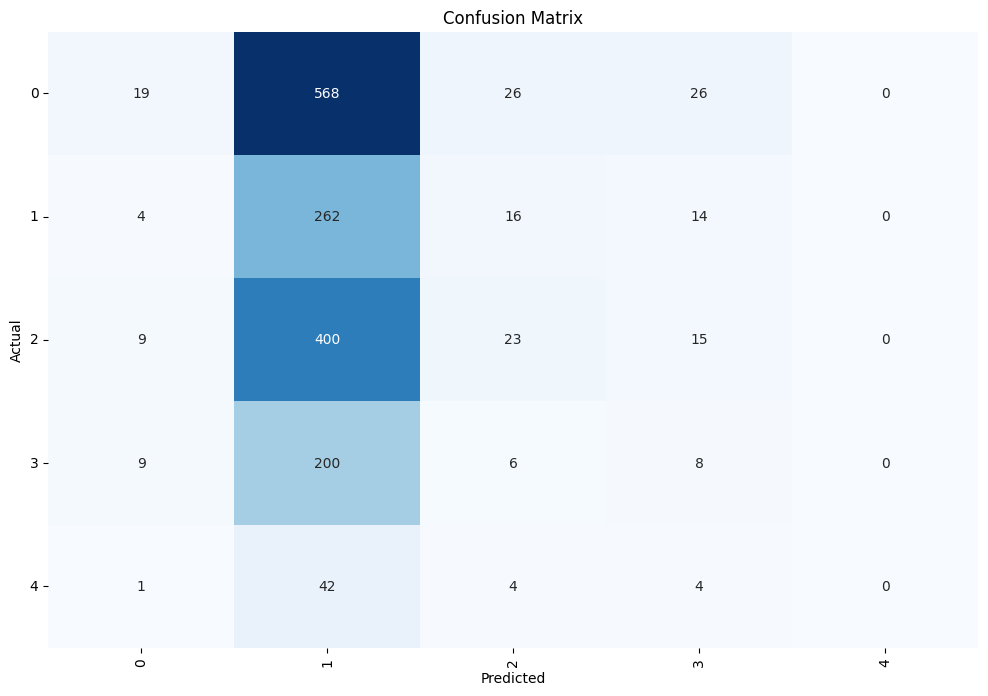

Classification Report:
----------------------
               precision    recall  f1-score   support

           0     0.4524    0.0297    0.0558       639
           1     0.1780    0.8851    0.2964       296
           2     0.3067    0.0515    0.0881       447
           3     0.1194    0.0359    0.0552       223
           4     0.0000    0.0000    0.0000        51

    accuracy                         0.1884      1656
   macro avg     0.2113    0.2004    0.0991      1656
weighted avg     0.3052    0.1884    0.1057      1656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
errors, tests=predictor(test_gen, test_steps)

In [24]:
new_history=model.fit(x=train_gen,  epochs=5, verbose=1, callbacks=callbacks,  validation_data=valid_gen,
               validation_steps=None,  shuffle=False,  initial_epoch=0)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 520ms/step - accuracy: 0.1816 - loss: 4.6271 - val_accuracy: 0.1768 - val_loss: 4.3621
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 507ms/step - accuracy: 0.2004 - loss: 4.1186 - val_accuracy: 0.2567 - val_loss: 3.8866
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 507ms/step - accuracy: 0.1960 - loss: 3.7239 - val_accuracy: 0.2542 - val_loss: 3.5082
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 511ms/step - accuracy: 0.1988 - loss: 3.3514 - val_accuracy: 0.2567 - val_loss: 3.2498
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 513ms/step - accuracy: 0.1964 - loss: 3.0459 - val_accuracy: 0.1864 - val_loss: 2.9068


23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 472ms/step
there were 1361 errors in 1656 tests for an accuracy of  17.81


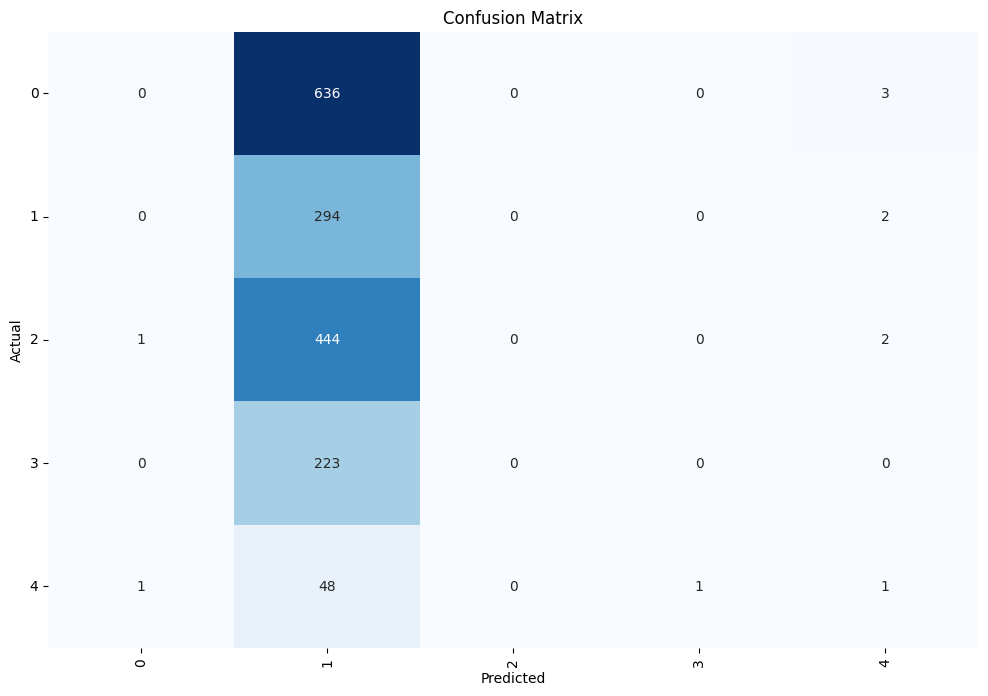

Classification Report:
----------------------
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       639
           1     0.1787    0.9932    0.3029       296
           2     0.0000    0.0000    0.0000       447
           3     0.0000    0.0000    0.0000       223
           4     0.1250    0.0196    0.0339        51

    accuracy                         0.1781      1656
   macro avg     0.0607    0.2026    0.0674      1656
weighted avg     0.0358    0.1781    0.0552      1656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
errors, tests=predictor(test_gen, test_steps)

In [26]:
new_history=model.fit(x=train_gen,  epochs=5, verbose=1, callbacks=callbacks,  validation_data=valid_gen,
               validation_steps=None,  shuffle=False,  initial_epoch=0)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 507ms/step - accuracy: 0.1756 - loss: 2.7791 - val_accuracy: 0.2119 - val_loss: 2.6591
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 503ms/step - accuracy: 0.1888 - loss: 2.5473 - val_accuracy: 0.1852 - val_loss: 2.4399
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 514ms/step - accuracy: 0.1880 - loss: 2.3494 - val_accuracy: 0.2567 - val_loss: 2.2590
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 499ms/step - accuracy: 0.1980 - loss: 2.1873 - val_accuracy: 0.2542 - val_loss: 2.1216
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 63s 501ms/step - accuracy: 0.1928 - loss: 2.0712 - val_accuracy: 0.0387 - val_loss: 2.0323


23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 410ms/step
there were 1574 errors in 1656 tests for an accuracy of   4.95


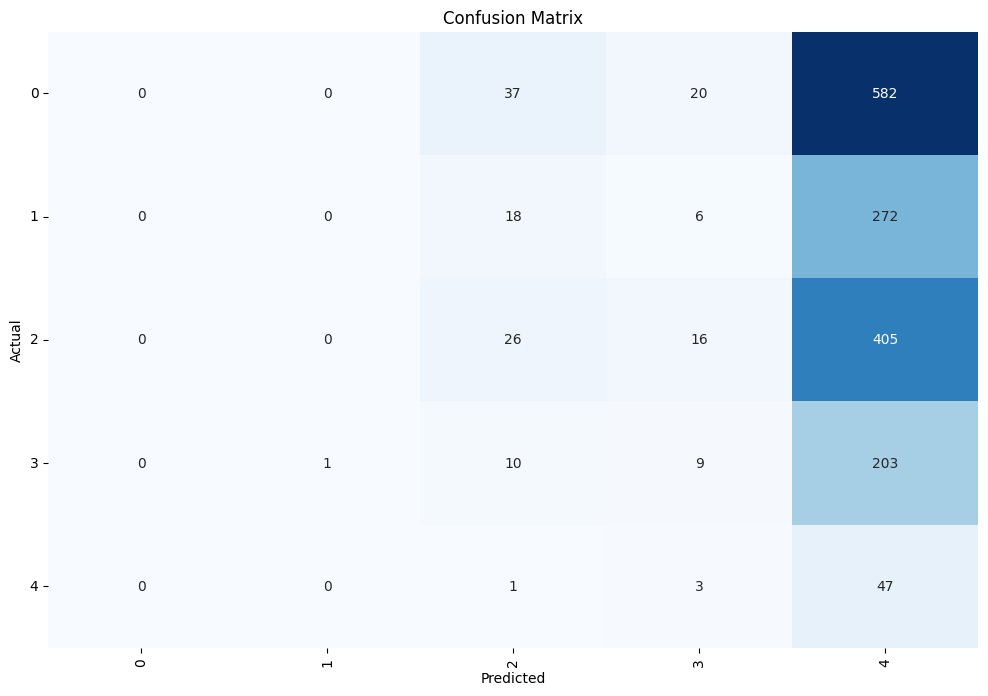

Classification Report:
----------------------
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       639
           1     0.0000    0.0000    0.0000       296
           2     0.2826    0.0582    0.0965       447
           3     0.1667    0.0404    0.0650       223
           4     0.0311    0.9216    0.0603        51

    accuracy                         0.0495      1656
   macro avg     0.0961    0.2040    0.0443      1656
weighted avg     0.0997    0.0495    0.0366      1656



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
errors, tests=predictor(test_gen, test_steps)

In [30]:
import os

# Define subject
subject = 'kneeEffNetB5'

# Calculate accuracy
acc = str((1 - errors / tests) * 100)

# Keep only 2 decimal places
index = acc.rfind('.')
acc = acc[:index + 3]

# Create file name
save_id = subject + '_' + acc + '.h5'

# Set working directory (IMPORTANT: define this properly)
working_dir = '/content/drive/MyDrive/Colab Notebooks'

# Full save path
model_save_loc = os.path.join(working_dir, save_id)

# Save model
model.save(model_save_loc)

print('Model was saved as:', model_save_loc)

Model was saved as: /content/drive/MyDrive/Colab Notebooks/kneeEffNetB5_4.95.h5
